In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. Wczytanie danych
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalizacja
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Dodanie kanału, bo Conv2D oczekuje (wys, szer, kanały)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# 2. Budowa prostej sieci CNN
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', name='conv1'),
    tf.keras.layers.MaxPooling2D((2, 2), name='pool1'),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', name='conv2'),
    tf.keras.layers.MaxPooling2D((2, 2), name='pool2'),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [4]:
# 3. Krótkie trenowanie
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.8349 - loss: 0.5597 - val_accuracy: 0.9813 - val_loss: 0.0651
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9786 - loss: 0.0667 - val_accuracy: 0.9838 - val_loss: 0.0556
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9850 - loss: 0.0477 - val_accuracy: 0.9873 - val_loss: 0.0408
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9898 - loss: 0.0343 - val_accuracy: 0.9893 - val_loss: 0.0370
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9911 - loss: 0.0287 - val_accuracy: 0.9893 - val_loss: 0.0406


In [5]:
# 4. Ocena modelu
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Dokładność na zbiorze testowym: {test_acc:.4f}")

Dokładność na zbiorze testowym: 0.9890


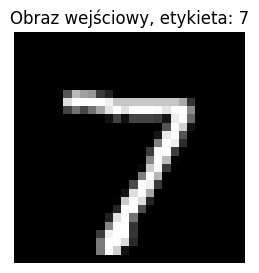

In [6]:
# 5. Wybór jednego obrazu testowego
sample_index = 0
sample_image = x_test[sample_index]
sample_label = y_test[sample_index]

plt.figure(figsize=(3, 3))
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Obraz wejściowy, etykieta: {sample_label}")
plt.axis('off')
plt.show()

In [9]:
# 6. Model do wyciągania aktywacji z warstw pośrednich
layer_outputs = [
    model.get_layer('conv1').output,
    model.get_layer('pool1').output,
    model.get_layer('conv2').output,
    model.get_layer('pool2').output
]

activation_model = tf.keras.Model(inputs=model.inputs[0], outputs=layer_outputs)

# Dodajemy wymiar batcha
sample_batch = np.expand_dims(sample_image, axis=0)

activations = activation_model.predict(sample_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


In [10]:
# 7. Funkcja do rysowania map cech
def plot_feature_maps(feature_maps, title, max_maps=16):
    """
    feature_maps: tensor o kształcie (1, H, W, C)
    """
    num_features = feature_maps.shape[-1]
    num_to_show = min(num_features, max_maps)

    cols = 4
    rows = int(np.ceil(num_to_show / cols))

    plt.figure(figsize=(12, 3 * rows))
    plt.suptitle(title, fontsize=16)

    for i in range(num_to_show):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
        plt.title(f"Mapa {i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()



Warstwa: conv1, kształt aktywacji: (1, 26, 26, 16)


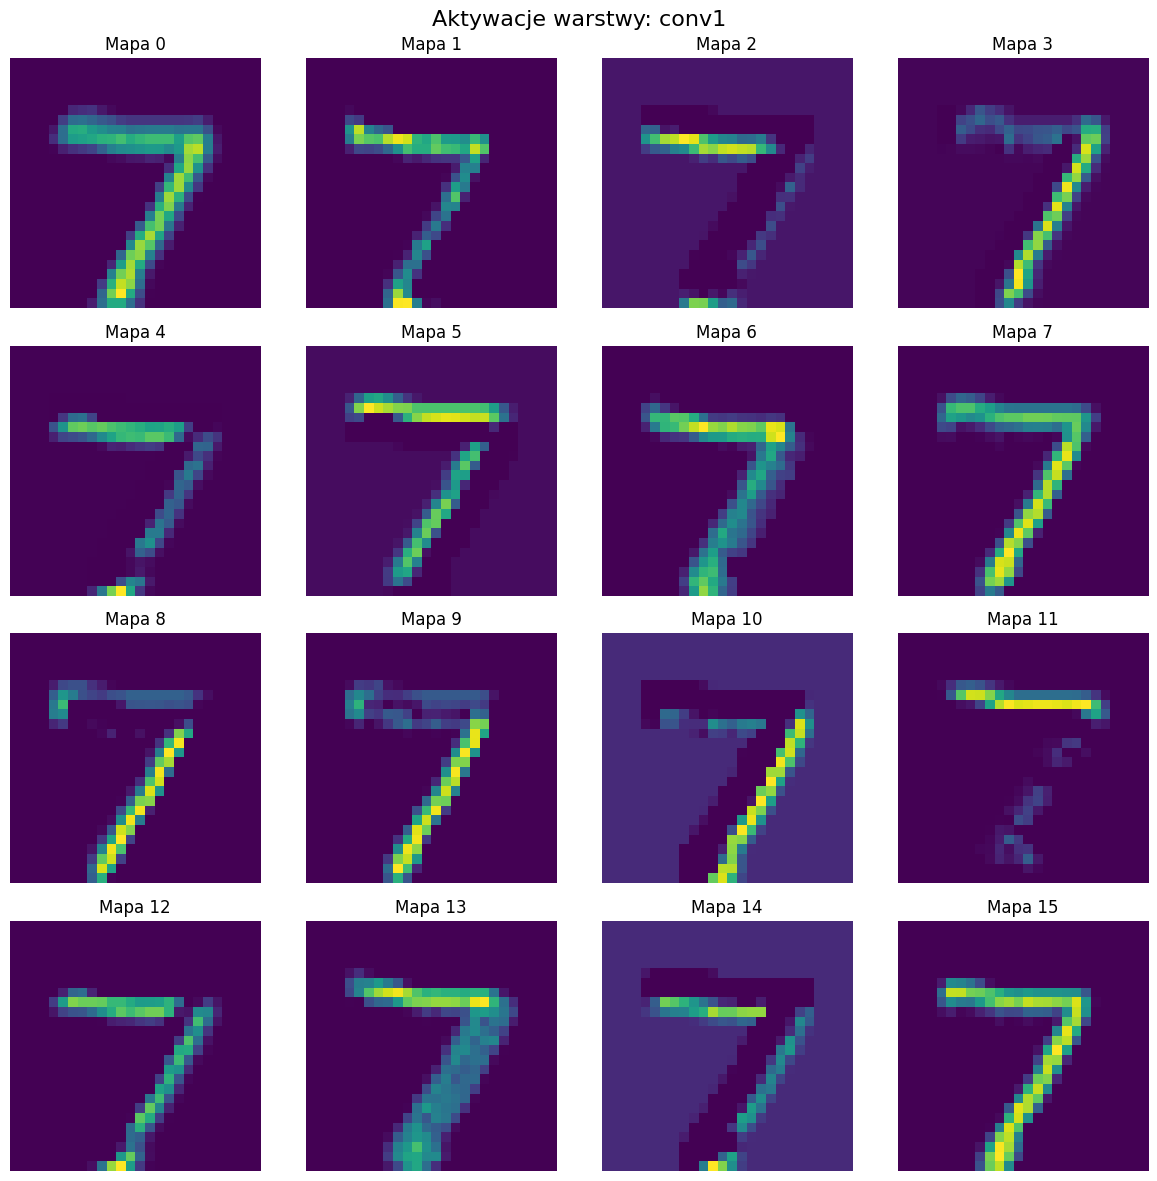


Warstwa: pool1, kształt aktywacji: (1, 13, 13, 16)


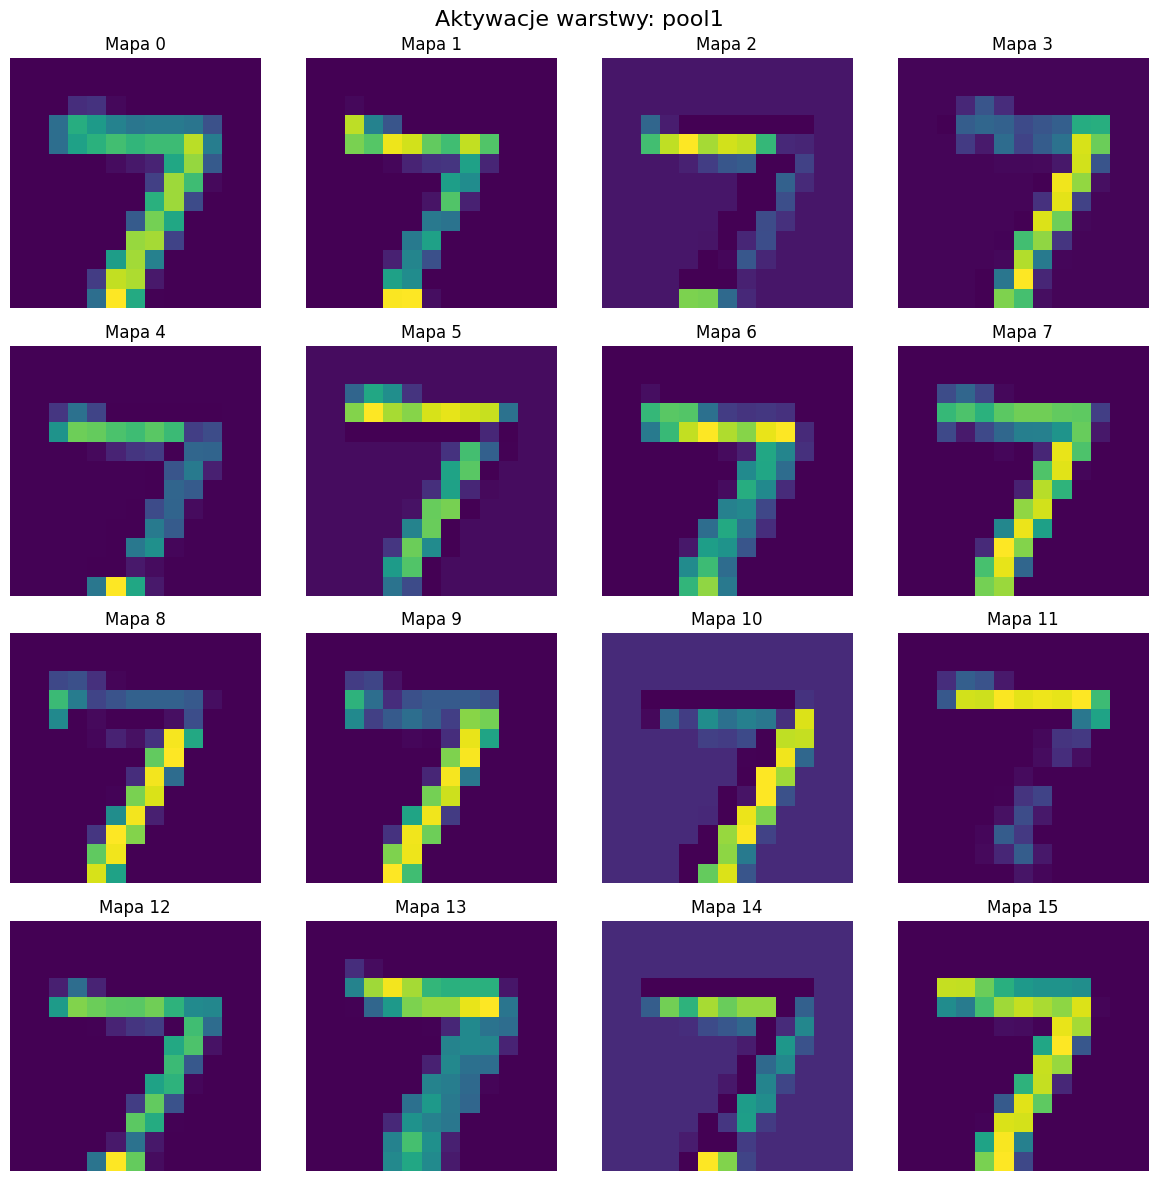


Warstwa: conv2, kształt aktywacji: (1, 11, 11, 32)


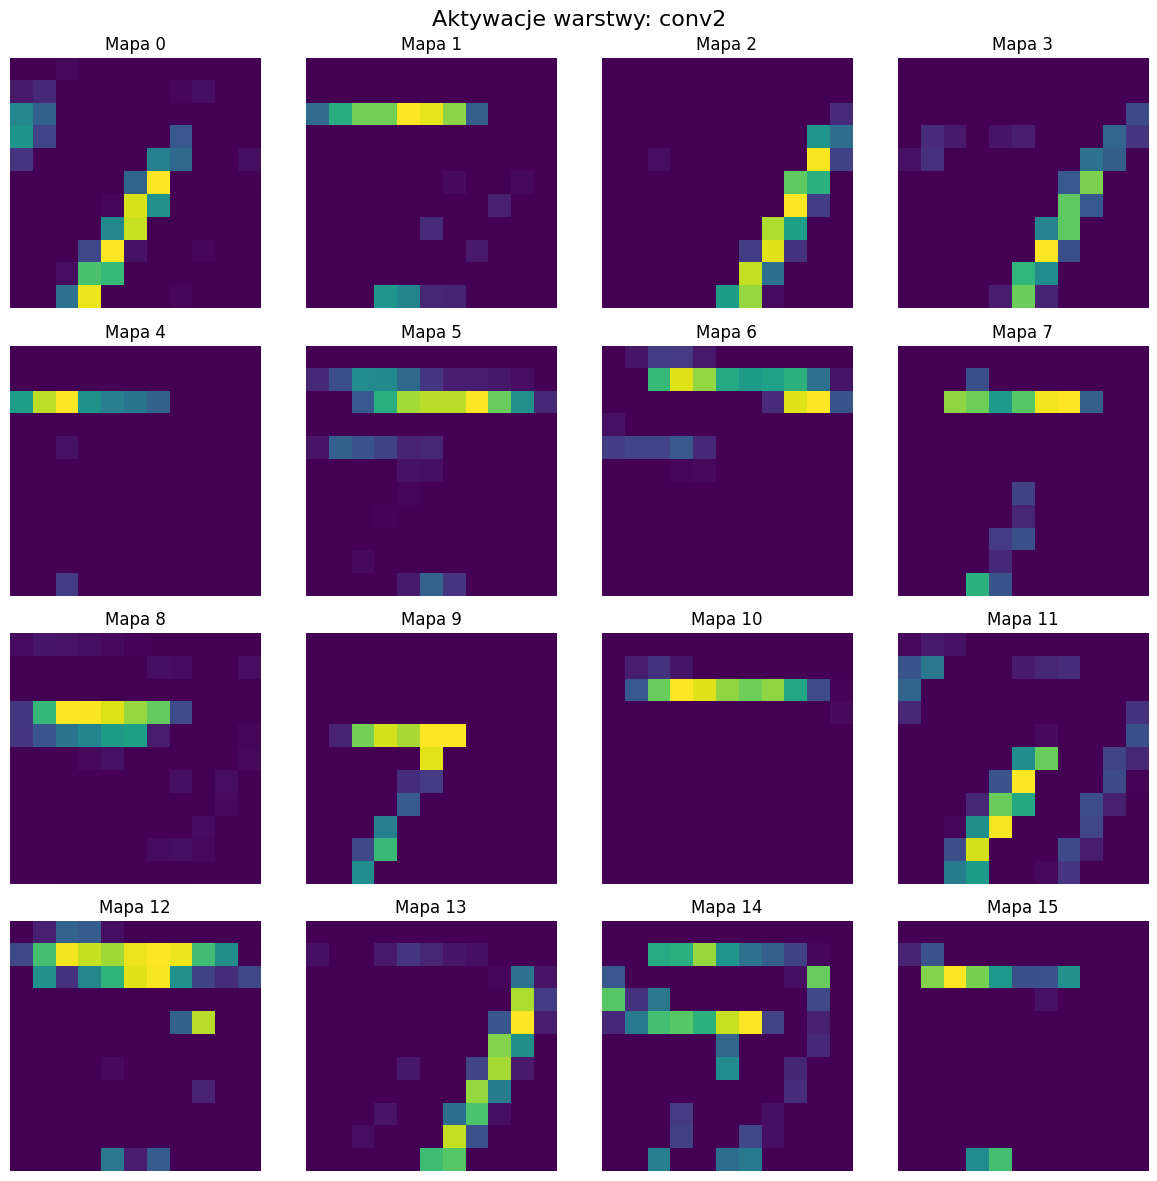


Warstwa: pool2, kształt aktywacji: (1, 5, 5, 32)


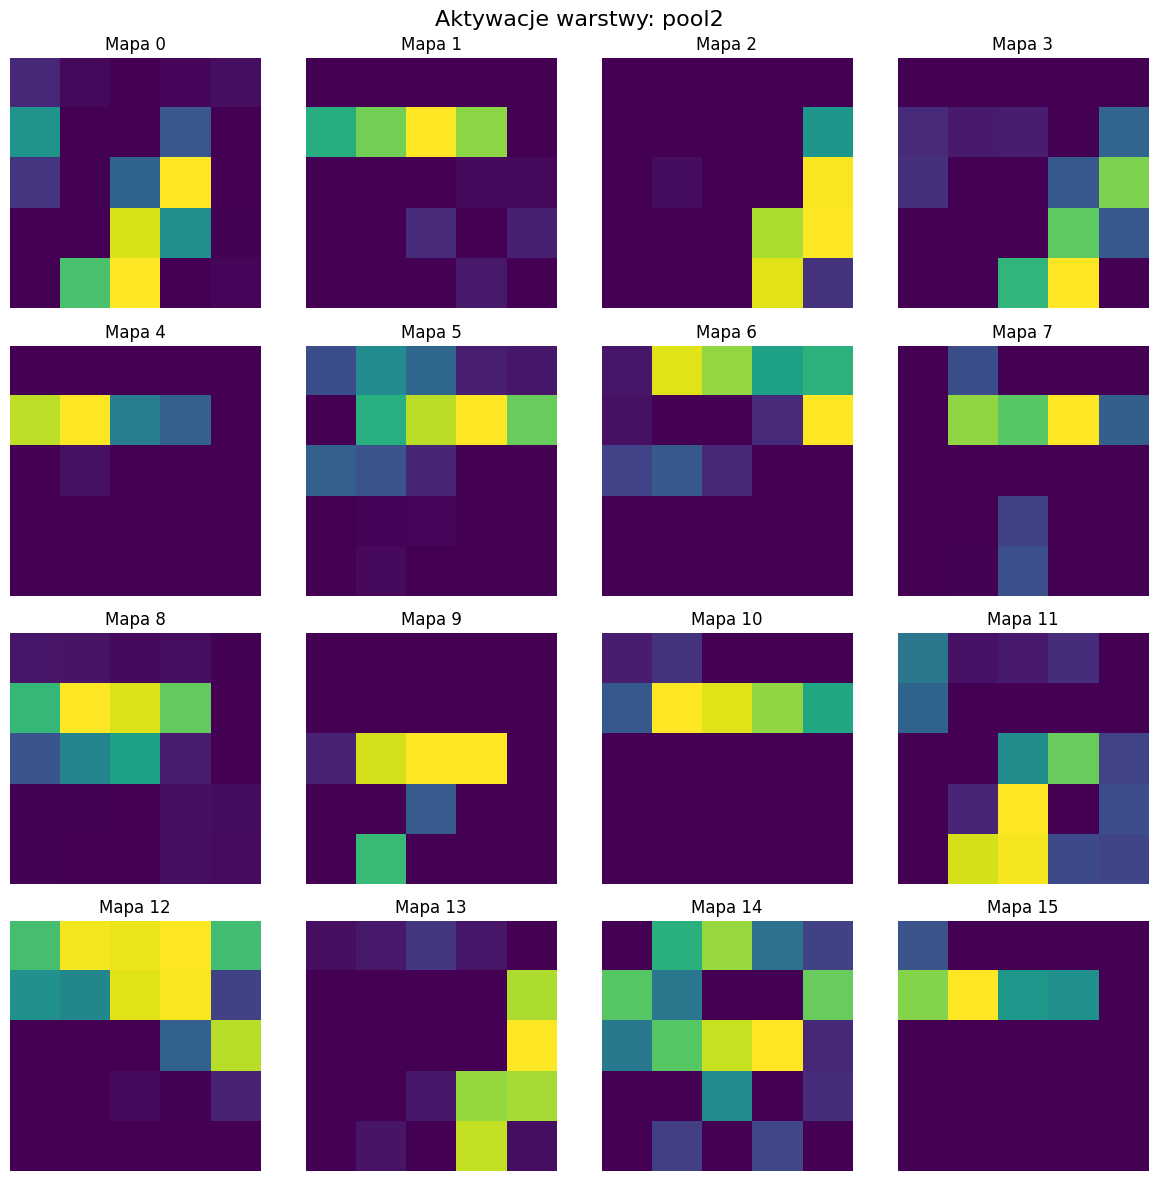

In [11]:
# 8. Wizualizacja aktywacji
layer_names = ['conv1', 'pool1', 'conv2', 'pool2']

for layer_name, activation in zip(layer_names, activations):
    print(f"\nWarstwa: {layer_name}, kształt aktywacji: {activation.shape}")
    plot_feature_maps(activation, f"Aktywacje warstwy: {layer_name}")